# ¿Qué es la Programación Orientada a Objetos (POO)?

La POO se basa en el concepto de “objetos”, que son entidades que combinan:

Atributos (datos) → variables que describen al objeto.

Métodos (comportamientos) → funciones que actúan sobre esos datos.

# EJEMPLO CEL MUNDO REAL

Un objeto puede ser un Auto →

Atributos: color, marca, velocidad.

Métodos: arrancar(), frenar(), acelerar().

# Que es una clase

- es un modelo o plantilla para crear objectos
en esta se definiran como seran sus atrubutos y sus metodos



In [2]:
class Auto:

    # atributos
   color = "Rojo"
   marca = "Toyota"

   # metodos
   def arrancar(self):
       print("El auto ha arrancado")

# ¿ Que es un Objecto? 

- es una instancia concreta de la clase,
es decir, creado a partir del molde de la clase

In [3]:
mi_auto = Auto()
print(mi_auto.color)  # Accediendo al atributo color
mi_auto.arrancar()

Rojo
El auto ha arrancado


l método __init__: el constructor

Cada vez que creas un objeto, Python ejecuta automáticamente el método especial __init__().
Sirve para inicializar los atributos del objeto.

In [5]:
class Auto:
    def __init__(self, marca, color):
        self.marca = marca
        self.color = color

    def mostrar_info(self):
        print(f"Marca: {self.marca}, Color: {self.color}")
        

Auto_1 = Auto("Toyota", "Rojo")
Auto_1.mostrar_info()
Auto_2 = Auto("Honda", "Azul")
Auto_2.mostrar_info()

Marca: Toyota, Color: Rojo
Marca: Honda, Color: Azul


# Atributos de clase vs. atributos de instancia

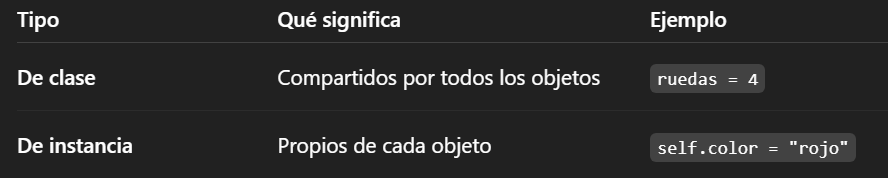

In [6]:
class Auto:
    ruedas = 4  # Atributo de clase

    def __init__(self, color):
        self.color = color  # Atributo de instancia

a1 = Auto("rojo")
a2 = Auto("azul")

print(a1.ruedas, a2.ruedas)
print(a1.color, a2.color)


4 4
rojo azul


# Métodos de instancia, clase y estáticos

➤ Método de instancia

Actúa sobre un objeto específico (self):

In [10]:
def acelerar(self):
    print(f"El {self.marca} acelera.")

acelerar(Auto_1)
acelerar(Auto_2)

El Toyota acelera.
El Honda acelera.


# METODO DE CLASE

- Se asocia a la clase, no al objeto. Usa @classmethod y cls.


In [11]:
class Auto:
    cantidad_autos = 0

    def __init__(self, marca):
        self.marca = marca
        Auto.cantidad_autos += 1

    @classmethod
    def total_autos(cls):
        print("Cantidad total de autos:", cls.cantidad_autos)


In [12]:
a1 = Auto("Toyota")
a2 = Auto("Mazda")
Auto.total_autos()


Cantidad total de autos: 2


➤ Método estático

No usa self ni cls.
Se usa para funciones relacionadas con la clase, pero que no dependen de ella.

In [13]:
class Calculadora:
    @staticmethod
    def sumar(a, b):
        return a + b

print(Calculadora.sumar(5, 3))  # 8


8


# Encapsulación (ocultar información)

Permite proteger datos internos de un objeto.
- Los atributos privados comienzan con __ y no deben modificarse fuera de la clase.


In [23]:
class Cuenta:
    def __init__(self, titular, saldo):
        self.titular = titular
        self.__saldo = saldo   # atributo "privado"

    def mostrar_saldo(self):
        print("Saldo:", self.__saldo)

cuenta1 = Cuenta("Alex", 5000)
cuenta1.mostrar_saldo()

# Intento de acceder directamente:
print(cuenta1.__saldo)  # Error


Saldo: 5000


AttributeError: 'Cuenta' object has no attribute '__saldo'

# Herencia (reutilizar clases)
Una clase puede heredar atributos y métodos de otra.

In [ ]:
class Persona:
    def __init__(self, nombre):
        self.nombre = nombre

    def saludar(self):
        print(f"Hola, soy {self.nombre}")

class Empleado(Persona):  # Hereda de Persona
    def __init__(self, nombre, puesto):
        super().__init__(nombre)  # Llama al constructor de Persona
        self.puesto = puesto

    def trabajar(self): # Nuevo método
        print(f"{self.nombre} está trabajando como {self.puesto}.")

e1 = Empleado("Alex", "Desarrollador")
e1.saludar()
e1.trabajar()


Hola, soy Alex
Alex está trabajando como Desarrollador.


# Polimorfismo (mismo método, distinto comportamiento)

Permite usar el mismo método en clases diferentes, pero con resultados distintos.

In [25]:
class Perro:
    def sonido(self):
        return "Guau"

class Gato:
    def sonido(self):
        return "Miau"

for animal in [Perro(), Gato()]:
    print(animal.sonido())


Guau
Miau


Métodos especiales (__str__, __len__, __eq__, etc.)

Python permite redefinir comportamientos internos con métodos mágicos (dunder methods, por “double underscore”).

In [29]:
class Persona:
    def __init__(self, nombre, edad):
        self.nombre = nombre
        self.edad = edad

    def __str__(self):
        return f"{self.nombre}, {self.edad} años"

    def __eq__(self, other):
        return self.edad == other.edad

p1 = Persona("Alex", 24)
p2 = Persona("Maria", 24)

print(p1)          # Alex, 24 años
print(p1 == p2)    # True


Alex, 24 años
True


In [30]:
# __len__ - Longitud
# Para qué sirve: Define qué devuelve len() en tu objeto

class Carrito:
    def __init__(self):
        self.productos = []
    
    def agregar(self, producto):
        self.productos.append(producto)
    
    def __len__(self):
        return len(self.productos)

carrito = Carrito()
carrito.agregar("Manzana")
carrito.agregar("Pan")
print(len(carrito))  # 2 (llama a __len__ automáticamente)

2


# Composición (objetos dentro de objetos)

In [31]:
class Motor:
    def __init__(self, potencia):
        self.potencia = potencia

class Auto:
    def __init__(self, marca, motor):
        self.marca = marca
        self.motor = motor

motor_v8 = Motor("400 HP")
auto = Auto("Chevrolet", motor_v8)
print(auto.marca, auto.motor.potencia)


Chevrolet 400 HP


# ESTILO PROFESIONAL:

In [32]:
class Persona:
    def __init__(self, nombre, edad):  # constructor
        self.nombre = nombre  #          atributos
        self.edad = edad

    def __str__(self):  # toString
        return f"{self.nombre} ({self.edad})"


class Empleado(Persona):
    def __init__(self, nombre, edad, salario):
        super().__init__(nombre, edad)
        self.__salario = salario # atributo privado

    @property   # getter y setter es decir get y set de salario que significa que podemos acceder a el salario como si fuera un atributo normal pero en realidad estamos usando metodos
    def salario(self):
        return self.__salario

    @salario.setter
    def salario(self, nuevo_salario):
        if nuevo_salario > 0:
            self.__salario = nuevo_salario
        else:
            raise ValueError("El salario debe ser positivo.")

    def __str__(self):
        return f"{self.nombre} ({self.edad}) - Salario: ${self.__salario}"


empleado = Empleado("Alex", 24, 3500)
print(empleado)
empleado.salario = 4000
print(empleado)


Alex (24) - Salario: $3500
Alex (24) - Salario: $4000
